In [1]:
# you should run it only first time
!pip uninstall -y plotly
!pip install plotly==5.20.0

Found existing installation: plotly 5.20.0
Uninstalling plotly-5.20.0:
  Successfully uninstalled plotly-5.20.0
  Using cached plotly-5.20.0-py3-none-any.whl.metadata (7.0 kB)
Using cached plotly-5.20.0-py3-none-any.whl (15.7 MB)


In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

sns.set(style="whitegrid")

In [3]:
# Завантаження датасету
!wget -O WorldHappinessReport.zip "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true"

--2026-03-21 15:51:05--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/WorldHappinessReport.zip [following]
--2026-03-21 15:51:05--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/WorldHappinessReport.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/WorldHappinessReport.zip [following]
--2026-03-21 15:51:05--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/WorldHappinessReport.zip
Resolving raw.githubusercontent.com (raw.githubuserco

In [4]:
!unzip -o WorldHappinessReport.zip

Archive:  WorldHappinessReport.zip
  inflating: 2015.csv                
  inflating: 2016.csv                
  inflating: 2017.csv                
  inflating: 2018.csv                
  inflating: 2019.csv                


In [5]:
# Перевірка файлів
all_files = glob.glob("**/*", recursive=True)
csv_files = [f for f in all_files if f.lower().endswith(".csv")]

print("CSV файли:")
for f in csv_files:
    print(f)

CSV файли:
2017.csv
2018.csv
2015.csv
2019.csv
2016.csv
sample_data/california_housing_train.csv
sample_data/mnist_train_small.csv
sample_data/california_housing_test.csv
sample_data/mnist_test.csv


In [6]:
target_file = None

for f in csv_files:
    if "2017" in os.path.basename(f): # обираємо данні за 2017 рік
        target_file = f
        break

if target_file is None and len(csv_files) > 0:
    target_file = csv_files[0]

print("Обраний файл:", target_file)

df = pd.read_csv(target_file)

Обраний файл: 2017.csv


In [9]:
print("Розмір датасету:", df.shape)
print("\nКолонки:")
print(df.columns.tolist())

print("\nПерші 3 рядки набору:")
df.head(3)

Розмір датасету: (155, 12)

Колонки:
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

Перші 3 рядки набору:


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715


In [10]:
df.info()

df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,155,155,Norway,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Happiness.Rank,155.0,NaN,NaN,NaN,78.0,44.888751,1.0,39.5,78.0,116.5,155.0
Happiness.Score,155.0,NaN,NaN,NaN,5.354019,1.13123,2.693,4.5055,5.279,6.1015,7.537
Whisker.high,155.0,NaN,NaN,NaN,5.452326,1.118542,2.864884,4.608172,5.370032,6.1946,7.62203
Whisker.low,155.0,NaN,NaN,NaN,5.255713,1.14503,2.521116,4.374955,5.193152,6.006527,7.479556
Economy..GDP.per.Capita.,155.0,NaN,NaN,NaN,0.984718,0.420793,0.0,0.663371,1.064578,1.318027,1.870766
Family,155.0,NaN,NaN,NaN,1.188898,0.287263,0.0,1.042635,1.253918,1.414316,1.610574
Health..Life.Expectancy.,155.0,NaN,NaN,NaN,0.551341,0.237073,0.0,0.369866,0.606042,0.723008,0.949492
Freedom,155.0,NaN,NaN,NaN,0.408786,0.149997,0.0,0.303677,0.437454,0.516561,0.658249
Generosity,155.0,NaN,NaN,NaN,0.246883,0.13478,0.0,0.154106,0.231538,0.323762,0.838075


In [12]:
# Перейменовуємо колонки для зручності
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"\.+", "_", regex=True)   # замінити . на _
    .str.replace(r"\s+", "_", regex=True)   # замінити " " на _
    .str.replace(r"_+", "_", regex=True)    # прибрати подвійні _
    .str.strip("_")
)
# змінюємо назву для зручності
df = df.rename(columns={
    "Economy_GDP_per_Capita": "GDP",
    "Health_Life_Expectancy": "Health",
    "Trust_Government_Corruption": "Trust",
    "Dystopia_Residual": "Dystopia"
})

print(df.columns.tolist())

['Country', 'Happiness_Rank', 'Happiness_Score', 'Whisker_high', 'Whisker_low', 'GDP', 'Family', 'Health', 'Freedom', 'Generosity', 'Trust', 'Dystopia']


Відбір числових ознак

In [13]:
# "Happiness_Rank" - лише для сортування що залежить від Score,
# "Dystopia" - частина score,
# Whisker.high / low - статистичні межі (error bars)
# Dystopia.Residual - частина формули

candidate_features = [
    "Happiness_Score",  # цільова змінна
    "GDP",              # економіка
    "Family",           # соціальна підтримка
    "Health",           # тривалість життя
    "Freedom",          # свобода
    "Trust",            # довіра до уряду
    "Generosity",       # соціальна поведінка
]
available_features = [col for col in candidate_features if col in df.columns]

print("Числові ознаки для аналізу:")
print(available_features)

Числові ознаки для аналізу:
['Happiness_Score', 'GDP', 'Family', 'Health', 'Freedom', 'Trust', 'Generosity']


In [15]:
numeric_df = df[available_features].copy()
numeric_df.head(3)

,Happiness_Score,GDP,Family,Health,Freedom,Trust,Generosity
0,7.537,1.616463,1.533524,0.796667,0.635423,0.315964,0.362012
1,7.522,1.482383,1.551122,0.792566,0.626007,0.400770,0.355280
2,7.504,1.480633,1.610574,0.833552,0.627163,0.153527,0.475540


Діаграми розподілу

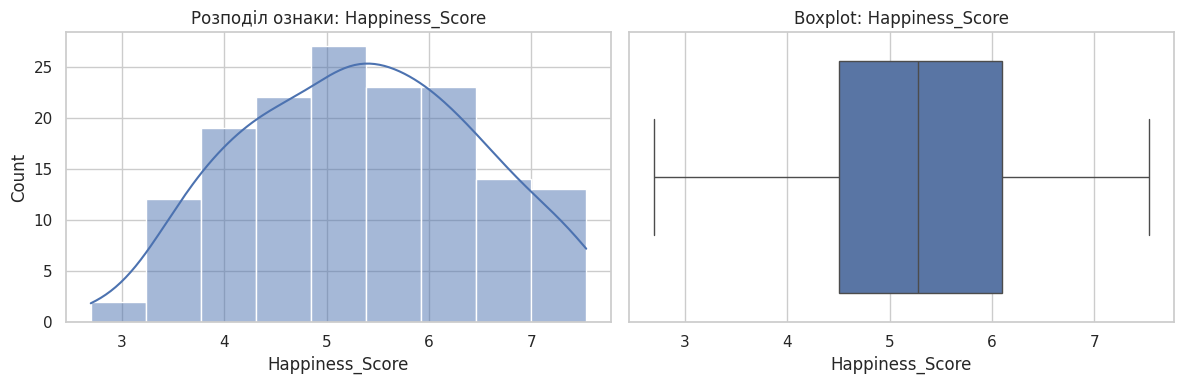

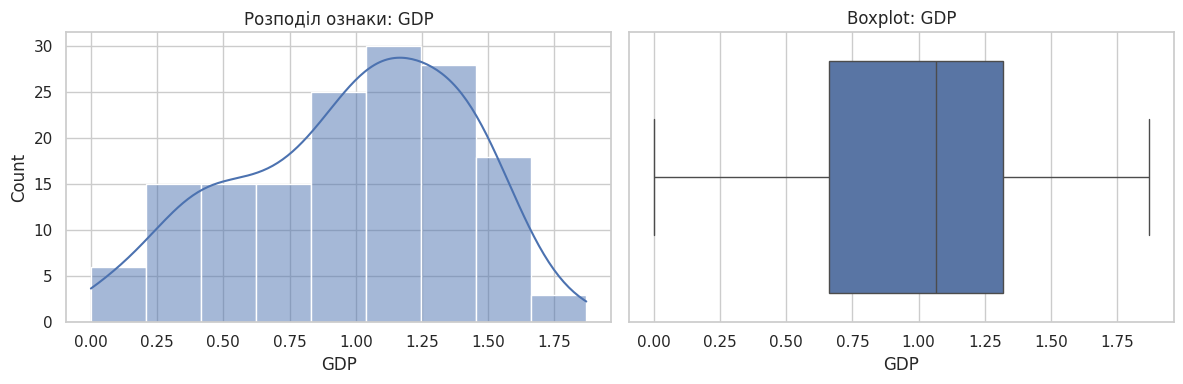

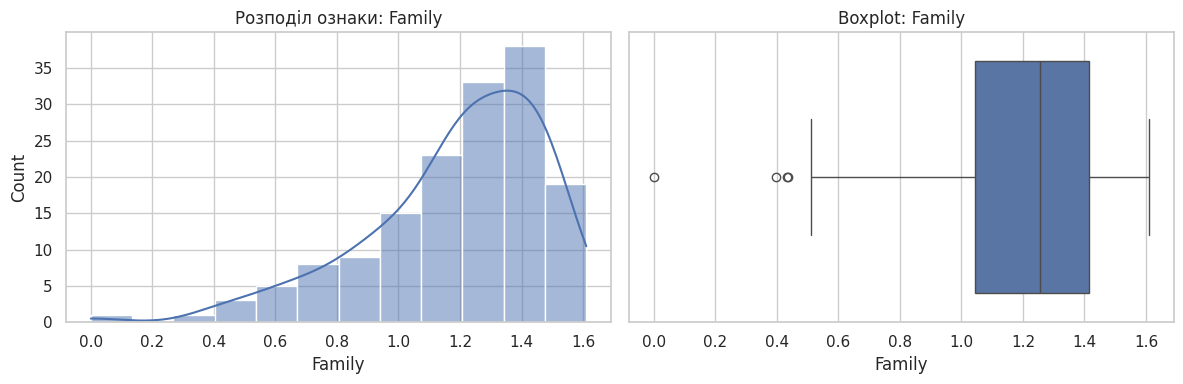

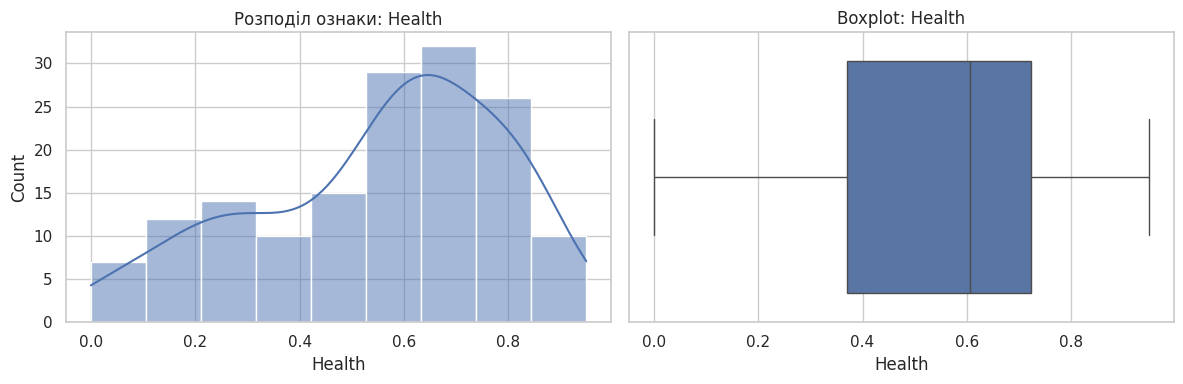

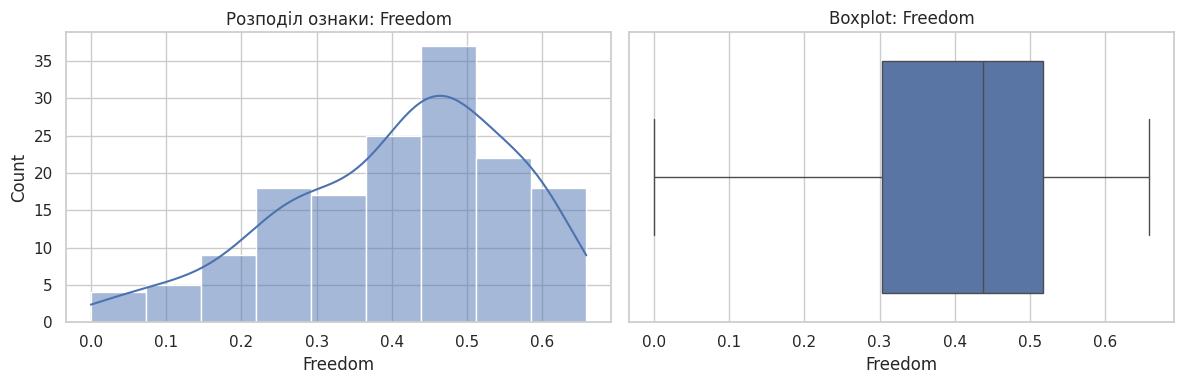

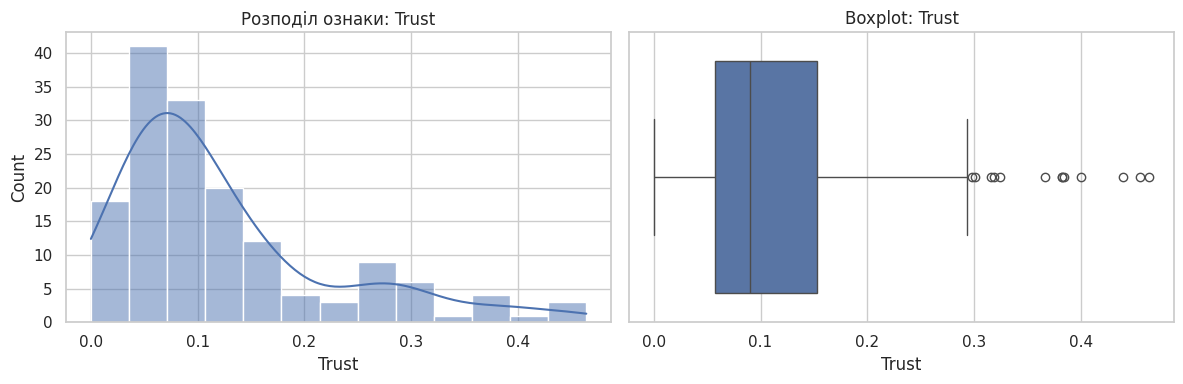

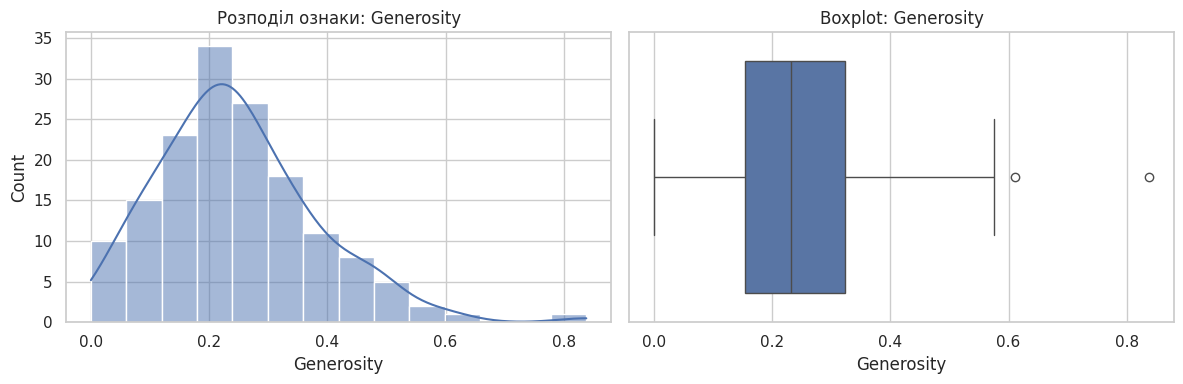

In [17]:
for col in numeric_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(numeric_df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Розподіл ознаки: {col}")

    # Boxplot
    sns.boxplot(x=numeric_df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()

Короткий текстовий аналіз нормальності

In [18]:
skewness_df = pd.DataFrame({
    "feature": numeric_df.columns,
    "skewness": [numeric_df[col].skew() for col in numeric_df.columns],
    "kurtosis": [numeric_df[col].kurt() for col in numeric_df.columns]
})

skewness_df

,feature,skewness,kurtosis
0,Happiness_Score,0.009554,-0.750419
1,GDP,-0.390693,-0.676755
2,Family,-1.181100,1.535250
3,Health,-0.577966,-0.585552
4,Freedom,-0.615766,-0.208406
5,Trust,1.476362,1.663740
6,Generosity,0.898715,1.743408


In [20]:
def interpret_distribution(skew_value):
    if abs(skew_value) < 0.5:
        return "приблизно симетричний"
    elif 0.5 <= abs(skew_value) < 1:
        return "помірно скошений"
    else:
        return "сильно скошений"

for _, row in skewness_df.iterrows():
    print(f"{row['feature']}: {interpret_distribution(row['skewness'])}, skew={row['skewness']:.3f}")

Happiness_Score: приблизно симетричний, skew=0.010
GDP: приблизно симетричний, skew=-0.391
Family: сильно скошений, skew=-1.181
Health: помірно скошений, skew=-0.578
Freedom: помірно скошений, skew=-0.616
Trust: сильно скошений, skew=1.476
Generosity: помірно скошений, skew=0.899


Було проведено аналіз нормальності розподілу ознак за допомогою коефіцієнтів асиметрії (skewness) та ексцесу (kurtosis).

Було встановлено, що ознаки Trust та Generosity мають значну правосторонню асиметрію та важкі хвости, що свідчить про відхилення від нормального розподілу.

Ознаки GDP, Health та Freedom мають незначні відхилення і можуть вважатися близькими до нормальних.

Отримані результати враховано при подальшій обробці даних перед кластеризацією.

In [21]:
def auto_transform(df):
    df_out = df.copy()
    report = []

    for col in df.columns:
        skew = df[col].skew()
        kurt = df[col].kurtosis()

        action = "none"

        # 1. сильний перекіс → log
        if skew > 1:
            df_out[col] = np.log1p(df_out[col])
            action = "log"

        # 2. сильні хвости → clipping
        if kurt > 1:
            q1 = df_out[col].quantile(0.25)
            q3 = df_out[col].quantile(0.75)
            iqr = q3 - q1

            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            df_out[col] = df_out[col].clip(lower, upper)

            action = "clip" if action == "none" else "log+clip"

        report.append({
            "feature": col,
            "skew": round(skew, 3),
            "kurtosis": round(kurt, 3),
            "action": action
        })

    report_df = pd.DataFrame(report)

    return df_out, report_df

In [22]:
X_clean, report = auto_transform(numeric_df)
print(report)

           feature   skew  kurtosis    action
0  Happiness_Score  0.010    -0.750      none
1              GDP -0.391    -0.677      none
2           Family -1.181     1.535      clip
3           Health -0.578    -0.586      none
4          Freedom -0.616    -0.208      none
5            Trust  1.476     1.664  log+clip
6       Generosity  0.899     1.743      clip


Було реалізовано rule-based підхід до обробки ознак.

Для ознак із високою асиметрією застосовано логарифмічне перетворення,
для ознак із важкими хвостами — обмеження значень (clipping),
а для ознак із обома проблемами — комбінований підхід.

Це дозволило автоматично адаптувати попередню обробку даних перед кластеризацією.

Кореляційна матриця

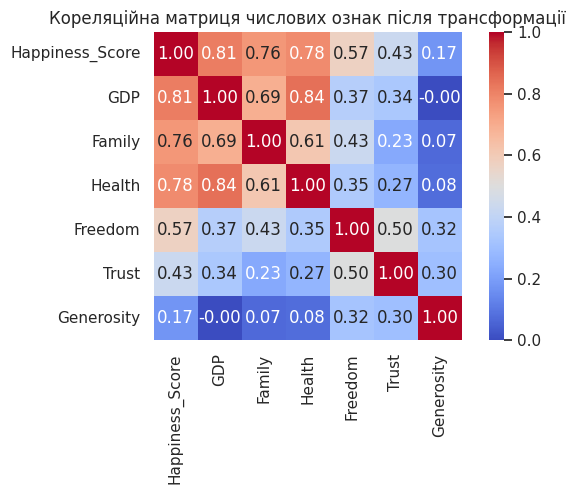

In [23]:
corr_matrix_clean = X_clean[available_features].corr()

plt.figure(figsize=(7, 4))
sns.heatmap(corr_matrix_clean, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Кореляційна матриця числових ознак після трансформації")
plt.show()

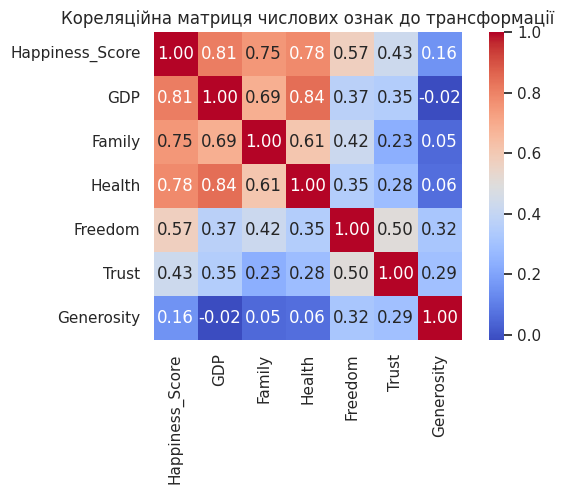

In [24]:
corr_matrix = numeric_df[available_features].corr()

plt.figure(figsize=(7, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Кореляційна матриця числових ознак до трансформації")
plt.show()

Аналіз кореляційної матриці показав наявність сильних позитивних лінійних зв’язків (0.75 - 0.85) між рівнем щастя та такими показниками, як GDP, Health та Family.
Це свідчить про значний вплив економічних, соціальних та медичних факторів на рівень щастя населення.

Ознаки Freedom та Trust мають помірний зв’язок (0.3 - 0.6) із рівнем щастя, що вказує на їх другорядну, але помітну роль.

Ознака Generosity демонструє слабкі кореляції (< 0.3) з іншими змінними, що свідчить про її відносну незалежність у даному наборі даних з однієї сторони, з іншого погляду зворотня за розподілом ознаки до Family. Generosity — майже незалежна ознака.

Порівняння матриць до та після трансформації показало, що структура взаємозв’язків між ознаками збереглася, що підтверджує коректність попередньої обробки даних.

Теплова мапа Happiness Score за країнами

In [25]:
import plotly.express as px

if "Country" in df.columns and "Happiness_Score" in df.columns:
    fig = px.choropleth(
        df,
        locations="Country",
        color="Happiness_Score",
        locationmode="country names",
        title="Happiness Index 2017"
    )
    fig.show()
else:
    print("Не знайдено колонки Country або Happiness_Score")

Стандартизація даних

In [26]:
def data_scale(data, scaler_type='minmax'):
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    else:
        raise ValueError("scaler_type має бути: 'minmax', 'std' або 'norm'")

    scaler.fit(data)
    res = scaler.transform(data)
    return res

In [27]:
imputer = SimpleImputer(strategy="mean")
X_imputed = pd.DataFrame(imputer.fit_transform(numeric_df), columns=available_features)

data_scaled_std = data_scale(X_imputed, scaler_type='std')
df_scaled_std = pd.DataFrame(data_scaled_std, columns=available_features)

data_scaled_minmax = data_scale(X_imputed, scaler_type='minmax')
df_scaled_minmax = pd.DataFrame(data_scaled_minmax, columns=available_features)

data_scaled_norm = data_scale(X_imputed, scaler_type='norm')
df_scaled_norm = pd.DataFrame(data_scaled_norm, columns=available_features)

In [28]:
print("Оригінальні дані:")
# numeric_df.describe().T
display(X_imputed.describe().T)

print("\nПісля StandardScaler:")
display(df_scaled_std.describe().T)

print("\nПісля MinMaxScaler:")
display(df_scaled_minmax.describe().T)

print("\nПісля Normalizer:")
display(df_scaled_norm.describe().T)

Оригінальні дані:


,count,mean,std,min,25%,50%,75%,max
Happiness_Score,155.0,5.354019,1.131230,2.693,4.505500,5.279000,6.101500,7.537000
GDP,155.0,0.984718,0.420793,0.000,0.663371,1.064578,1.318027,1.870766
Family,155.0,1.188898,0.287263,0.000,1.042635,1.253918,1.414316,1.610574
Health,155.0,0.551341,0.237073,0.000,0.369866,0.606042,0.723008,0.949492
Freedom,155.0,0.408786,0.149997,0.000,0.303677,0.437454,0.516561,0.658249
Trust,155.0,0.123120,0.101661,0.000,0.057271,0.089848,0.153296,0.464308
Generosity,155.0,0.246883,0.134780,0.000,0.154106,0.231538,0.323762,0.838075



Після StandardScaler:


,count,mean,std,min,25%,50%,75%,max
Happiness_Score,155.0,-2.750488e-16,1.003241,-2.359949,-0.752517,-0.066532,0.662910,1.935996
GDP,155.0,-2.750488e-16,1.003241,-2.347736,-0.766147,0.190399,0.794666,2.112488
Family,155.0,3.667317e-16,1.003241,-4.152125,-0.510811,0.227076,0.787253,1.472669
Health,155.0,-2.292073e-16,1.003241,-2.333157,-0.767962,0.231482,0.726457,1.684893
Freedom,155.0,2.750488e-16,1.003241,-2.734123,-0.703009,0.191745,0.720845,1.668506
Trust,155.0,-9.168293e-17,1.003241,-1.215016,-0.649839,-0.328353,0.297794,3.367022
Generosity,155.0,1.203339e-16,1.003241,-1.837684,-0.690591,-0.114221,0.572250,4.400552



Після MinMaxScaler:


,count,mean,std,min,25%,50%,75%,max
Happiness_Score,155.0,0.549343,0.233532,0.0,0.374174,0.533856,0.703654,1.0
GDP,155.0,0.526372,0.224931,0.0,0.354599,0.569060,0.704539,1.0
Family,155.0,0.738183,0.178361,0.0,0.647369,0.778553,0.878144,1.0
Health,155.0,0.580669,0.249684,0.0,0.389541,0.638280,0.761467,1.0
Freedom,155.0,0.621021,0.227873,0.0,0.461341,0.664573,0.784751,1.0
Trust,155.0,0.265169,0.218951,0.0,0.123346,0.193509,0.330161,1.0
Generosity,155.0,0.294584,0.160821,0.0,0.183881,0.276274,0.386317,1.0



Після Normalizer:


,count,mean,std,min,25%,50%,75%,max
Happiness_Score,155.0,0.950109,0.012974,0.904764,0.943308,0.949392,0.957514,0.989429
GDP,155.0,0.168244,0.055368,0.000000,0.135794,0.183678,0.204014,0.273066
Family,155.0,0.211400,0.040648,0.000000,0.192515,0.208411,0.234501,0.312276
Health,155.0,0.094512,0.032816,0.000000,0.078688,0.103052,0.112263,0.158723
Freedom,155.0,0.072658,0.025633,0.000000,0.057120,0.076660,0.086648,0.156659
Trust,155.0,0.021483,0.016171,0.000000,0.010319,0.017450,0.029666,0.122566
Generosity,155.0,0.045520,0.026797,0.000000,0.026136,0.043293,0.059670,0.173943


Було проведено порівняння статистик оригінального набору даних та після застосування різних методів масштабування.

Оригінальні дані мають різні масштаби ознак (mean GDP ~1, mean Score ~5, std ≈ різний масштаб), модель “перекошується”, що може негативно впливати на результати алгоритмів кластеризації.

Після застосування StandardScaler всі ознаки були приведені до єдиного масштабу з середнім значенням, близьким до нуля, та стандартним відхиленням, близьким до одиниці, дані центровані, що є оптимальним для алгоритму Gaussian Mixture.

MinMaxScaler також привів дані до єдиного діапазону [0,1], однак не усуває вплив викидів, зберігає skew.

Метод Normalizer нормалізує дані по рядках, що призводить до втрати відносних відмінностей між об'єктами, перетворює значення у пропорції при якій кожен об'єкт масштабується відносно своєї довжини, тому він є менш придатним для задачі кластеризації.

Таким чином, StandardScaler є найбільш доцільним методом масштабування для подальшої кластеризації.

Gaussian Mixture на стандартизованих даних

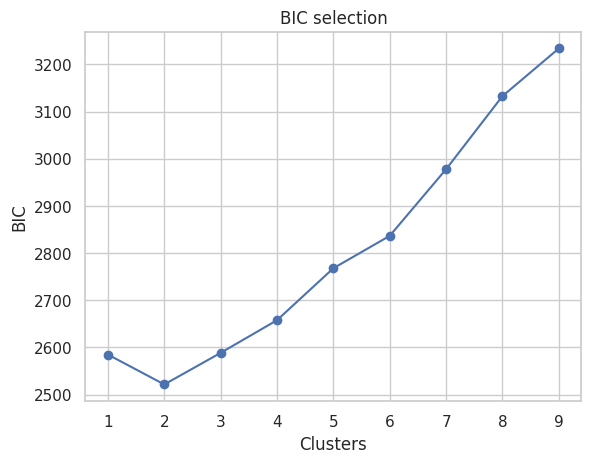

In [29]:
import matplotlib.pyplot as plt

X_cluster = df_scaled_std.copy()

bic = []
k_range = range(1, 10)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_cluster)
    bic.append(gmm.bic(X_cluster))

plt.plot(k_range, bic, marker='o')
plt.xlabel("Clusters")
plt.ylabel("BIC")
plt.title("BIC selection")
plt.show()

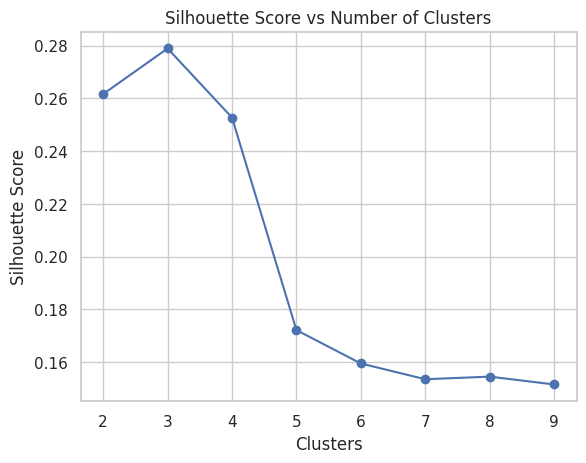

In [30]:
from sklearn.metrics import silhouette_score

k_range = range(2, 10)

scores = []
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    #print(k, score)
    scores.append(score)

plt.plot(k_range, scores, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

Оптимальну кількість кластерів було визначено за допомогою двох методів: інформаційного критерію BIC та метрики silhouette score.

Метрика silhouette score обчислюється лише для випадків, коли кількість кластерів не менше двох, оскільки вона базується на порівнянні відстаней між кластерами.

На відміну від неї, інформаційний критерій BIC може бути обчислений і для одного кластера, оскільки оцінює якість апроксимації даних моделлю незалежно від наявності кількох кластерів.
BIC показав мінімум при k=2, що свідчить про наявність двох основних груп у даних.
Однак silhouette score досягає максимального значення при k=3, що вказує на більш чітке розділення об'єктів у просторі ознак.

З огляду на інтерпретованість результатів та кращу геометричну структуру кластерів, було обрано k=3 як оптимальне значення.

In [31]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

clusters = gmm.fit_predict(X_cluster)

df_result = df.copy()
df_result["Cluster"] = clusters

# df_result[["Country", "Cluster"]].head() if "Country" in df_result.columns else df_result[["Cluster"]].head()

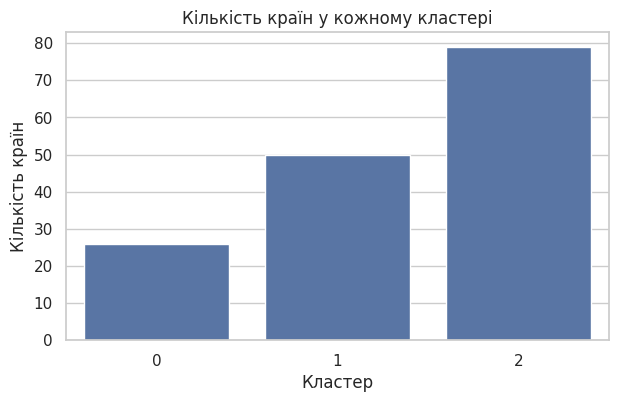

In [32]:
# Розподіл країн по кластерах
plt.figure(figsize=(7, 4))
sns.countplot(data=df_result, x="Cluster")
plt.title("Кількість країн у кожному кластері")
plt.xlabel("Кластер")
plt.ylabel("Кількість країн")
plt.show()

Середні значення ознак по кластерах

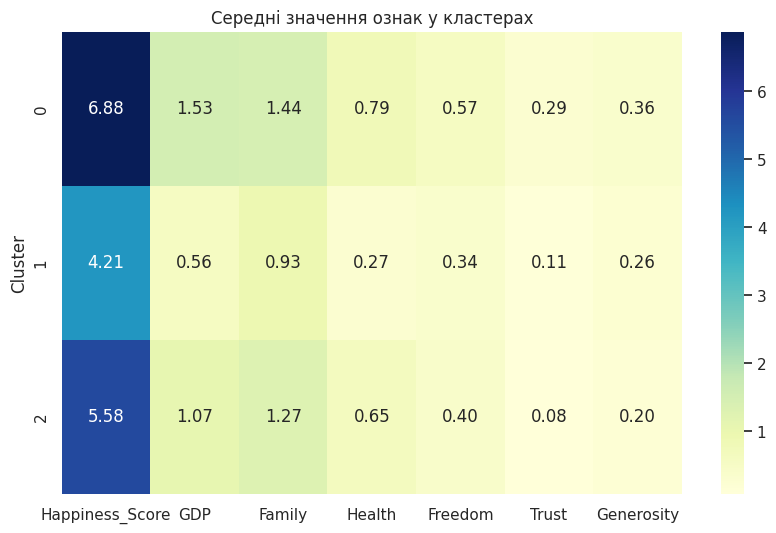

In [33]:
cluster_profile = df_result.groupby("Cluster")[available_features].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Середні значення ознак у кластерах")
plt.show()

Теплова мапа кластерів по країнах

In [34]:
if "Country" in df_result.columns:
    fig = px.choropleth(
        df_result,
        locations="Country",
        color="Cluster",
        locationmode="country names",
        title="Clusters of Countries (Gaussian Mixture)"
    )
    fig.show()
else:
    print("Колонка Country не знайдена")

Дослідити вплив різного набору ознак

In [35]:
def run_gmm_experiment(df, features):
    # 1. Вибір ознак
    X = df[features].copy()

    # 2. Заповнення пропусків
    imputer = SimpleImputer(strategy="mean")
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features)

    # 3. Масштабування
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=features)

    # 4. Пошук найкращого k
    scores = {}
    for k in range(2, 7):
        gmm = GaussianMixture(n_components=k, random_state=42)
        labels = gmm.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores[k] = score

    best_k = max(scores, key=scores.get)

    # 5. Фінальна модель
    gmm_best = GaussianMixture(n_components=best_k, random_state=42)
    clusters = gmm_best.fit_predict(X_scaled)

    # 6. Профіль кластерів
    df_temp = X_imputed.copy()
    df_temp["Cluster"] = clusters
    cluster_profile = df_temp.groupby("Cluster").mean()

    return {
        "features": features,
        "best_k": best_k,
        "scores": scores,
        "clusters": clusters,
        "profile": cluster_profile
    }

In [36]:
feature_sets = {
    "set_1": ["Happiness_Score"],
    "set_2": ["GDP", "Family", "Health"],
    "set_3": ["Freedom", "Trust"],
    "set_4": ["Generosity"],
    "set_5": ["GDP", "Family", "Health", "Freedom", "Trust"],
    "set_6": [f for f in available_features if f != "Happiness_Score"],
    "set_7": ["Freedom", "Trust", "Generosity"]
}

In [37]:
results = {}

for name, features in feature_sets.items():
    results[name] = run_gmm_experiment(df, features)

In [38]:
for name, res in results.items():
    print(f"{name}: best_k = {res['best_k']}, best_score = {max(res['scores'].values()):.4f}")

set_1: best_k = 3, best_score = 0.5842
set_2: best_k = 2, best_score = 0.3775
set_3: best_k = 2, best_score = 0.4705
set_4: best_k = 2, best_score = 0.5761
set_5: best_k = 2, best_score = 0.2942
set_6: best_k = 3, best_score = 0.2690
set_7: best_k = 2, best_score = 0.4432


У ході дослідження було проаналізовано вплив різних наборів ознак на результат кластеризації країн методом Gaussian Mixture та оцінено якість кластеризації за допомогою silhouette score.

Отримані результати показали, що найвища якість кластеризації досягається при використанні одновимірних ознак, зокрема Happiness_Score (silhouette ≈ 0.58) та Generosity (≈ 0.57). Це пояснюється тим, що в одному вимірі дані мають природний упорядкований розподіл, і алгоритму легше розділити їх на групи.

Разом з тим, такі результати не можна вважати повністю змістовними, оскільки кластеризація за однією ознакою фактично відтворює її ж ранжування і не враховує комплексний вплив інших факторів.

При використанні більшої кількості ознак (наприклад, набори set_5 та set_6) значення silhouette score зменшується (≈ 0.29–0.27), що свідчить про більш складну структуру даних та часткове перекриття кластерів у багатовимірному просторі. Це є очікуваним результатом, оскільки рівень щастя країни формується під впливом багатьох факторів, які не завжди мають чітке розділення.

Водночас саме багатовимірні набори ознак є більш репрезентативними для реального розподілу країн, оскільки враховують економічні, соціальні та інституційні характеристики.

Таким чином, можна зробити висновок, що:
- прості моделі з однією ознакою дають кращі метрики якості, але не відображають реальної структури даних;
- моделі з кількома ознаками мають нижчі значення silhouette score, проте краще відповідають реальному розподілу країн за рівнем щастя;
- результат кластеризації суттєво залежить від вибору ознак, що підтверджує необхідність їх обґрунтованого підбору.

Отже, кластеризація методом Gaussian Mixture частково відображає оригінальний розподіл країн за рівнем щастя, але її інтерпретація повинна враховувати складність багатовимірного простору ознак.